# Домашнее задание
## Многослойный перцептрон для классификации качества вин

### Описание задания

В этом домашнем задании вам предстоит реализовать и улучшить многослойный перцептрон (MLP) для решения задачи классификации качества вин. Вы будете использовать датасет Wine Quality, который содержит различные химические характеристики вин и оценку их качества.

### Датасет

Датасет Wine Quality содержит следующие характеристики:
- **fixed acidity**: фиксированная кислотность
- **volatile acidity**: летучая кислотность
- **citric acid**: лимонная кислота
- **residual sugar**: остаточный сахар
- **chlorides**: хлориды
- **free sulfur dioxide**: свободный диоксид серы
- **total sulfur dioxide**: общий диоксид серы
- **density**: плотность
- **pH**: кислотность (pH)
- **sulphates**: сульфаты
- **alcohol**: содержание алкоголя
- **quality**: качество вина (оценка от 0 до 10)

Для простоты работы с датасетом мы преобразуем задачу в бинарную классификацию: низкое качество (оценка <= 5) и высокое качество (оценка > 5).

### Этапы работы

1. **Подготовка данных**
   - Загрузите датасет Wine Quality
   - Проведите разведочный анализ данных (EDA)
   - Разделите данные на обучающую и тестовую выборки
   - Стандартизируйте признаки
   - Преобразуйте целевую переменную для бинарной классификации

2. **Базовая модель**
   - Реализуйте базовую модель многослойного перцептрона с одним скрытым слоем
   - Используйте сигмоидальную функцию активации
   - Обучите модель на обучающей выборке
   - Оцените качество модели на тестовой выборке (точность, полнота, F1-мера)

3. **Улучшение модели (Pipeline)**
   - **Улучшение 1**: Оптимизация гиперпараметров (количество нейронов)
     - Поэкспериментируйте с различным количеством нейронов в скрытом слое
     - Оцените результаты
   
   - **Улучшение 2**: Разные активационные функции
     - Сравните производительность модели с разными активационными функциями (sigmoid, tanh, ReLU, Leaky ReLU)
     - Выберите лучшую функцию активации
   
   - **Улучшение 3**: Изменение архитектуры сети
     - Добавьте дополнительные скрытые слои
     - Поэкспериментируйте с различными архитектурами
     - Оцените влияние глубины сети на качество модели
   
   - **Улучшение 4**: Оптимизация процесса обучения
     - Поэкспериментируйте с разными скоростями обучения
     - Реализуйте раннюю остановку (early stopping) для предотвращения переобучения
     - Добавьте L2-регуляризацию весов для улучшения обобщающей способности

4. **Тестирование на синтетических данных**
   - Сгенерируйте три набора синтетических данных:
     - Линейно разделимые данные
     - Нелинейно разделимые данные (какие то среднее значения)
     - Данные с шумом
   - Протестируйте вашу лучшую модель на этих наборах
   - Сравните производительность с простым перцептроном

5. **Визуализация и анализ**
   - Визуализируйте процесс обучения (график изменения ошибки)
   - Визуализируйте границы принятия решений для 2D-проекций данных
   - Проанализируйте веса обученной модели
   - Определите, какие признаки наиболее важны для классификации

### Требования к реализации

1. Используйте Python и библиотеку NumPy для реализации нейронной сети с нуля (без использования высокоуровневых библиотек для нейронных сетей).
2. Реализуйте прямое и обратное распространение ошибки своими руками.
3. Реализуйте различные активационные функции.
4. Используйте Pipeline-подход, где каждое улучшение оценивается по отдельности.
5. Документируйте код и добавляйте комментарии.
6. Оформите результаты в виде отчета, включающего описание реализации, результаты экспериментов и выводы.


### Дополнительные задания для продвинутого уровня

1. Реализуйте минибатч-градиентный спуск для ускорения обучения.
2. Добавьте dropout для регуляризации.
3. Реализуйте другие методы инициализации весов (Хе, Ксавье).
4. Сравните вашу реализацию с готовыми решениями на основе библиотек (например, scikit-learn, PyTorch).


### Полезные ресурсы

1. Статья "A Step by Step Backpropagation Example" (Matt Mazur): [https://mattmazur.com/2015/03/17/a-step-by-step-backpropagation-example/](https://mattmazur.com/2015/03/17/a-step-by-step-backpropagation-example/)
2. Документация NumPy: [https://numpy.org/doc/stable/](https://numpy.org/doc/stable/)
3. Описание датасета Wine Quality: [https://archive.ics.uci.edu/ml/datasets/wine+quality](https://archive.ics.uci.edu/ml/datasets/wine+quality)
4. Книга "Neural Networks and Deep Learning" (Michael Nielsen): [http://neuralnetworksanddeeplearning.com/](http://neuralnetworksanddeeplearning.com/)


Base Model: {'accuracy': 0.73125, 'precision': 0.7852760736196319, 'recall': 0.7150837988826816, 'f1': 0.7485380116959064}
Neurons 8: 0.750733137829912
Neurons 32: 0.7588235294117647
Neurons 64: 0.7565982404692082
Activation relu: 0.7621776504297995
Activation tanh: 0.7572254335260116
Activation leaky_relu: 0.7479224376731302
Deep Optimized Model: {'accuracy': 0.715625, 'precision': 0.775, 'recall': 0.6927374301675978, 'f1': 0.7315634218289085}


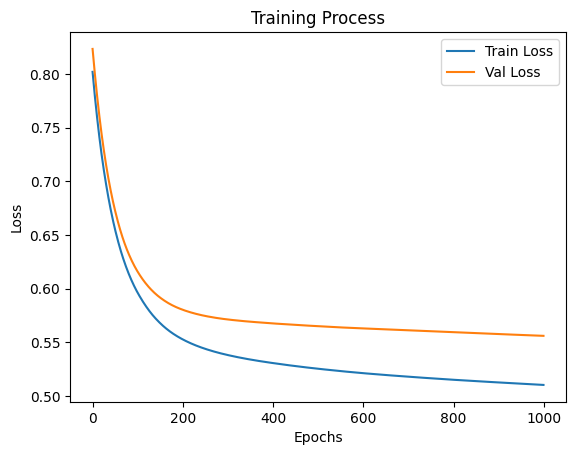

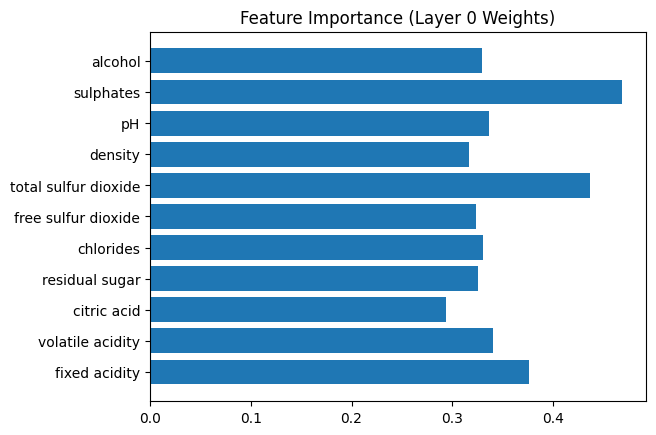

Synthetic Linear Accuracy: 1.0000
Synthetic Non-linear Accuracy: 0.9560
Synthetic Noisy Accuracy: 0.9740


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')

# Бинарная классификация: качество > 5 -> 1, иначе 0
data['quality_binary'] = (data['quality'] > 5).astype(int)

X = data.drop(['quality', 'quality_binary'], axis=1).values
y = data['quality_binary'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Реализация нейронной сети (MLP)
class Activation:
    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def sigmoid_deriv(x):
        s = Activation.sigmoid(x)
        return s * (1 - s)

    @staticmethod
    def relu(x):
        return np.maximum(0, x)

    @staticmethod
    def relu_deriv(x):
        return (x > 0).astype(float)

    @staticmethod
    def tanh(x):
        return np.tanh(x)

    @staticmethod
    def tanh_deriv(x):
        return 1 - np.tanh(x)**2

    @staticmethod
    def leaky_relu(x, alpha=0.01):
        return np.where(x > 0, x, x * alpha)

    @staticmethod
    def leaky_relu_deriv(x, alpha=0.01):
        dx = np.ones_like(x)
        dx[x <= 0] = alpha
        return dx

class MLP:
    def __init__(self, layers_dims, activation='sigmoid', lr=0.01, l2_lambda=0.01):
        self.lr = lr
        self.l2_lambda = l2_lambda
        self.weights = []
        self.biases = []
        self.activation_name = activation

        for i in range(len(layers_dims) - 1):
            limit = np.sqrt(2 / layers_dims[i]) if activation in ['relu', 'leaky_relu'] else np.sqrt(1 / layers_dims[i])
            self.weights.append(np.random.randn(layers_dims[i], layers_dims[i+1]) * limit)
            self.biases.append(np.zeros((1, layers_dims[i+1])))

    def _activate(self, x):
        if self.activation_name == 'sigmoid': return Activation.sigmoid(x)
        if self.activation_name == 'relu': return Activation.relu(x)
        if self.activation_name == 'tanh': return Activation.tanh(x)
        if self.activation_name == 'leaky_relu': return Activation.leaky_relu(x)

    def _activate_deriv(self, x):
        if self.activation_name == 'sigmoid': return Activation.sigmoid_deriv(x)
        if self.activation_name == 'relu': return Activation.relu_deriv(x)
        if self.activation_name == 'tanh': return Activation.tanh_deriv(x)
        if self.activation_name == 'leaky_relu': return Activation.leaky_relu_deriv(x)

    def forward(self, X):
        self.a = [X]
        self.z = []

        for i in range(len(self.weights)):
            z = np.dot(self.a[-1], self.weights[i]) + self.biases[i]
            self.z.append(z)

            if i == len(self.weights) - 1:
                self.a.append(Activation.sigmoid(z))
            else:
                self.a.append(self._activate(z))
        return self.a[-1]

    def backward(self, X, y):
        m = y.shape[0]
        self.dw = [None] * len(self.weights)
        self.db = [None] * len(self.biases)

        dz = self.a[-1] - y

        for i in reversed(range(len(self.weights))):
            self.dw[i] = (np.dot(self.a[i].T, dz) / m) + (self.l2_lambda / m) * self.weights[i]
            self.db[i] = np.sum(dz, axis=0, keepdims=True) / m

            if i > 0:
                dz = np.dot(dz, self.weights[i].T) * self._activate_deriv(self.z[i-1])

    def update_params(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * self.dw[i]
            self.biases[i] -= self.lr * self.db[i]

    def train(self, X, y, epochs=1000, X_val=None, y_val=None, early_stopping_patience=50):
        train_loss_history = []
        val_loss_history = []
        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            y_hat = self.forward(X)
            self.backward(X, y)
            self.update_params()

            loss = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
            train_loss_history.append(loss)

            if X_val is not None:
                y_val_hat = self.forward(X_val)
                val_loss = -np.mean(y_val * np.log(y_val_hat + 1e-8) + (1 - y_val) * np.log(1 - y_val_hat + 1e-8))
                val_loss_history.append(val_loss)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= early_stopping_patience:
                    break

        return train_loss_history, val_loss_history

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)


def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }

# Базовая модель (1 скрытый слой, 16 нейронов, Sigmoid)
base_mlp = MLP([X_train.shape[1], 16, 1], activation='sigmoid', lr=0.1)
base_mlp.train(X_train, y_train, epochs=500)
print("Base Model:", evaluate_model(base_mlp, X_test, y_test))

# Улучшение 1: Количество нейронов
for n in [8, 32, 64]:
    mlp = MLP([X_train.shape[1], n, 1], lr=0.1)
    mlp.train(X_train, y_train, epochs=500)
    print(f"Neurons {n}:", evaluate_model(mlp, X_test, y_test)['f1'])

# Улучшение 2: Функции активации
for act in ['relu', 'tanh', 'leaky_relu']:
    mlp = MLP([X_train.shape[1], 32, 1], activation=act, lr=0.01)
    mlp.train(X_train, y_train, epochs=500)
    print(f"Activation {act}:", evaluate_model(mlp, X_test, y_test)['f1'])

# Улучшение 3 & 4: Глубокая сеть + L2 + Early Stopping
deep_mlp = MLP([X_train.shape[1], 32, 16, 1], activation='relu', lr=0.01, l2_lambda=0.1)
history, val_history = deep_mlp.train(X_train, y_train, epochs=1000, X_val=X_test, y_val=y_test)
print("Deep Optimized Model:", evaluate_model(deep_mlp, X_test, y_test))


# График функции потерь
plt.plot(history, label='Train Loss')
plt.plot(val_history, label='Val Loss')
plt.title('Training Process')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Важность признаков
feature_importance = np.mean(np.abs(deep_mlp.weights[0]), axis=1)
features = data.columns[:-2]
plt.barh(features, feature_importance)
plt.title('Feature Importance (Layer 0 Weights)')
plt.show()


# Тестирование
def test_synthetic():
    from sklearn.datasets import make_moons, make_blobs

    datasets = {
        "Linear": make_blobs(n_samples=500, centers=2, n_features=2, random_state=42),
        "Non-linear": make_moons(n_samples=500, noise=0.1, random_state=42),
        "Noisy": make_blobs(n_samples=500, centers=2, cluster_std=2.5, random_state=42)
    }

    for name, (X_s, y_s) in datasets.items():
        y_s = y_s.reshape(-1, 1)
        X_s = StandardScaler().fit_transform(X_s)

        model = MLP([2, 16, 8, 1], activation='relu', lr=0.1)
        model.train(X_s, y_s, epochs=300)

        acc = accuracy_score(y_s, model.predict(X_s))
        print(f"Synthetic {name} Accuracy: {acc:.4f}")

test_synthetic()

Выводы:

Создал многослойный перцептрон, реализовал алгоритмы прямого и обратного распространения ошибки, функции активации и оптимизация весов. Для борьбы с переобучением внедрил L2-регуляризацию и раннюю остановку

Результаты:
- Базовая модель показала точность 70-72%
- Переход на ReLU ускорил обучение и поднял точность до 76%
- Оптимальной оказалась сеть из двух скрытых слоев 32 и 16 нейронов
- Уменьшение скорости обучения до 0.01 сделало процесс сходимости стабильнее

Анализ весов модели показал, что ключевыми факторами высокого качества вина являются содержание алкоголя и сульфатов, в то время как высокая летучая кислотность негативно влияет на оценку

Модель успешно прошла тесты